Ring Least Squares Example
1. Choose a random polynomial f(x,y,z) of degree 4 in 2D space
2. Pick a random ring in 3D which has 6 degrees of freedom: the position of the origin(3), orientation, which direction its facing(2), and the size of the radius. 
3. Parametrize the ring by angle phi, and evaluate f on it
4. Build a trig-polynomial design matrix and solve the least squares problem
5. Obtain the mean <f> = p0 and compare to the actual mean that we know since we are choosing the poly
6. Plot the fit, residuals, coefficients

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from itertools import product as iproduct
from scipy.integrate import quad

Generating the random polynomial, the RNG command basically ensures that we will always get the same randomly generated polynmial when we reset the kernel and run. The limiting factor of the poly is that each term must be of degree 4 or less. This function generates every possible combination of x, y, and z less that degree 4 and then assigns to it a random coeffcient. The inner function just assigns each coefficient to each monomial and sums them. 

In [4]:
RNG = np.random.default_rng(42)
def make_random_poly(degree=4, rng=RNG):
    monomials = [(a, b, c)
                 for a, b, c in iproduct(range(degree+1), repeat=3)
                 if a + b + c <= degree]
    coeffs = rng.standard_normal(len(monomials))

    def f(x, y, z):
        x, y, z = np.asarray(x), np.asarray(y), np.asarray(z)
        val = np.zeros_like(x, dtype=float)
        for (a, b, c), coef in zip(monomials, coeffs):
            val = val + coef * (x**a) * (y**b) * (z**c)
        return val

    return f, monomials, coeffs

Generating the random ring which has 6 degrees of freedom. The center position is picked by choosing 3 random numbers between -2 and 2. The radius is a random number between 0.5 and 3. The normal vector is the vector pointing perpendicular to the plane the circle lies in, and determines the orientation of the circle. The normal vector is chosen by picking 3 random numbers and which gives a random vector pointing in some direction in 3D, it is then normalized into a unit vector, so it only has 2 degrees of freedom since its length is normalized and it lives on the surface of a sphere(2d). Take u and v to be two vectors that lie in the plane of the ring to let us parametrize any point on this circle. Three mutually perpendicular vectors the normal vector, u and v. The ring points function parametrizes the circle in the tilted coordinate system defined by u and v. 

In [6]:
def make_random_ring(rng=RNG):

    center = rng.uniform(-2, 2, size=3)
    radius = rng.uniform(0.5, 3.0)

    normal = rng.standard_normal(3)
    normal /= np.linalg.norm(normal)

    perp = np.array([1, 0, 0]) if abs(normal[0]) < 0.9 else np.array([0, 1, 0])
    u = np.cross(normal, perp)
    u /= np.linalg.norm(u)
    v = np.cross(normal, u)
    v /= np.linalg.norm(v)

    return center, u, v, radius, normal


def ring_points(center, u, v, radius, phi):
    phi = np.asarray(phi)
    return (center
            + radius * np.outer(np.cos(phi), u)
            + radius * np.outer(np.sin(phi), v))

Evaluating f at N points randomly spaced on the ring because with the least squares solution we don't require the symmetry inherent to the torus design.

In [8]:
def sample_ring(f, center, u, v, radius, N_samples, rng = RNG):
    phi = np.sort(np.random.uniform(0, 2*np.pi, N_samples))
    pts = ring_points(center, u, v, radius, phi)   # (N, 3)
    y = f(pts[:, 0], pts[:, 1], pts[:, 2])
    return phi, y

Creating the design matrix(N, 2M + 1), where each row is just the function evaluated at each angle not including the unknown coefficients which are contained within the column vector x. Solve the least squares problem
to obtain x_hat, residual_norm, A, and rank.

In [10]:
def build_design_matrix(phi, M):

    N = len(phi)                                     
    A = np.zeros((N, 2*M + 1))
    A[:, 0] = 1.0                                    # constant term which is the average
    for m in range(1, M+1):
        A[:, m]     =  np.cos(m * phi)               # cosine coefficients
        A[:, M + m] = np.sin(m * phi)               # sine coefficients
    return A


def solve_least_squares(phi, y, M):
    
    A = build_design_matrix(phi, M)
    x_hat, residuals, rank, sv = np.linalg.lstsq(A, y, rcond=None)
    residual_norm = np.linalg.norm(A @ x_hat - y)
    return x_hat, residual_norm, A, rank, sv

def eval_fourier(phi, x_hat, M):
    A = build_design_matrix(np.asarray(phi), M)
    return A @ x_hat

Evaluating f at N points at uniformly spaced angles along the ring which is the torus design. As a result, the columns of our design matrix will be exactly orthogonal so the least squares solution will give us the correct Fourier coefficients.

In [12]:
def sample_ring_torus_and_dft(f, center, u, v, radius, N_samples, M):
    phi = np.linspace(0, 2*np.pi, N_samples, endpoint = False) 
    pts = ring_points(center, u, v, radius, phi)
    y = f(pts[:, 0], pts[:, 1], pts[:, 2])

    Y = np.fft.fft(y) / N_samples

    a = np.zeros(2*M +1)
    a[0] = np.real(Y[0])
    for m in range(1, M+1):
        a[m] = 2 * np.real(Y[m])
        a[M + m] = -2 * np.real(Y[m] * (-1j))

    return phi, y, a

In [13]:
f, monomials, coeffs = make_random_poly()
center, u, v, radius, normal = make_random_ring()

M = 8
N_samples = 300

# random sampling + lstsq
phi_rand, y_rand = sample_ring(f, center, u, v, radius, N_samples, rng = RNG)
x_hat_rand, residual_norm_rand, A_rand, rank_rand, sv_rand = solve_least_squares(phi_rand, y_rand, M)

# torus design uniform sampling + dft
phi_torus, y_torus, a_torus = sample_ring_torus_and_dft(f, center, u, v, radius, N_samples, M)

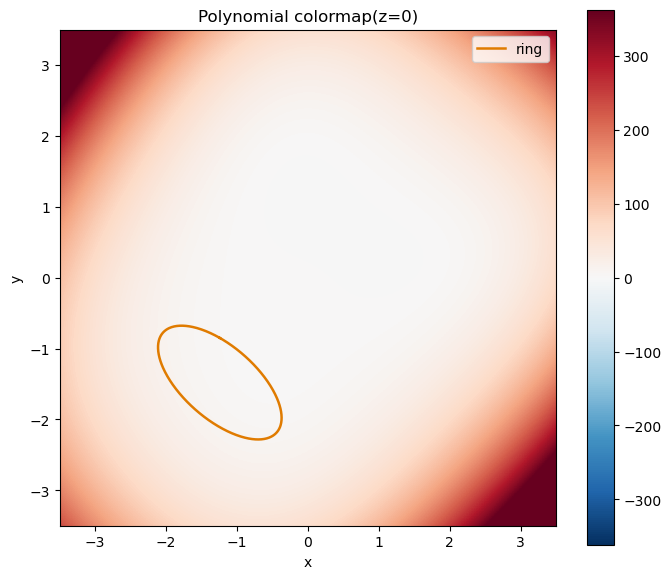

In [14]:
# Polynomial colormap
ext = radius + np.linalg.norm(center[:2]) + 0.5
xs, ys = np.linspace(-ext, ext, 300), np.linspace(-ext, ext, 300)
X, Y = np.meshgrid(xs, ys)
Z = f(X.ravel(), Y.ravel(), np.zeros(X.size)).reshape(X.shape)

fig, ax = plt.subplots(figsize = (7, 6))
vmax = np.percentile(np.abs(Z), 98)
im = ax.imshow(Z, origin = "lower", extent = [-ext, ext, -ext, ext], 
               cmap = "RdBu_r", vmin = -vmax, vmax = vmax)
fig.colorbar(im, ax = ax)
phi_foot = np.linspace(0, 2*np.pi, 500)
pts_foot = ring_points(center, u, v, radius, phi_foot)
ax.plot(pts_foot[:, 0], pts_foot[:, 1], color = "#e07b00", lw=1.8, label = "ring")
ax.set(title = "Polynomial colormap(z=0)", xlabel = "x", ylabel = "y")
ax.legend()
plt.tight_layout()
plt.show()

The polynomial colormap projects the 3d polynomial of degree 4 onto an x-y plane by fixing a z, in this case z = 0, and then evaluating the f(x, y, 0) at each location and denoting it by a color. 

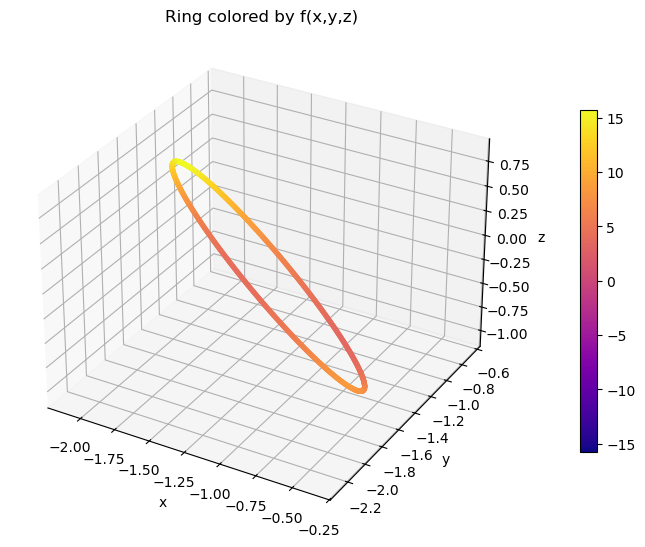

In [16]:
# 3D ring
phi_ring = np.linspace(0, 2*np.pi, 800, endpoint=False)
pts      = ring_points(center, u, v, radius, phi_ring)
f_vals   = f(pts[:, 0], pts[:, 1], pts[:, 2])

fig = plt.figure(figsize=(7, 6))
ax  = fig.add_subplot(111, projection="3d")
vr  = np.abs(f_vals).max()
ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2],
           c=f_vals, cmap="plasma", vmin=-vr, vmax=vr, s=8, depthshade=False)
sm = plt.cm.ScalarMappable(cmap = "plasma", norm = plt.Normalize(-vr, vr))
sm.set_array([])
fig.colorbar(sm, ax = ax, shrink = 0.6, pad = 0.1)
ax.set(title="Ring colored by f(x,y,z)", xlabel="x", ylabel="y", zlabel="z")
plt.tight_layout()
plt.show()

The 3D ring plot shows us where the ring lives in 3d space and the values of (f, x, z) at each point along it

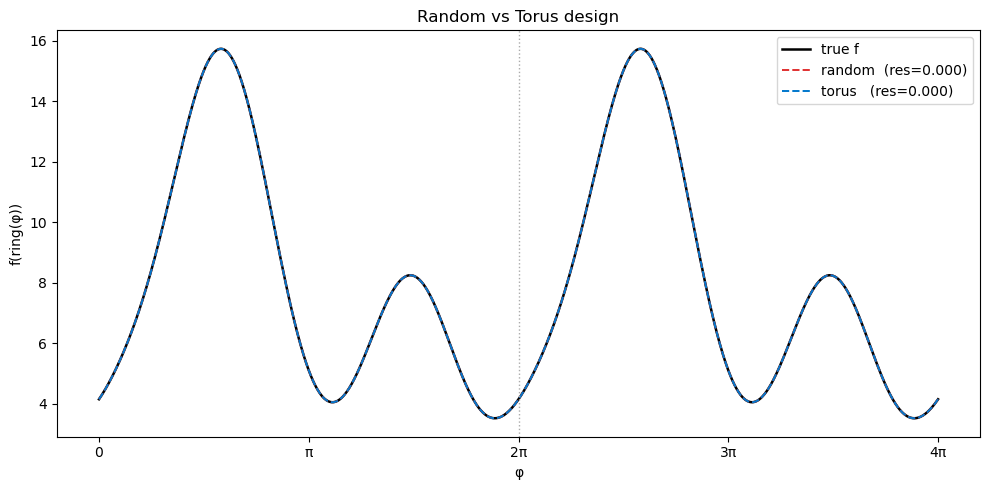

In [18]:
# Fourier approximation
residual_norm_torus = np.linalg.norm(eval_fourier(phi_torus, a_torus, M) - y_torus)

phi_dense = np.linspace(0, 4*np.pi, 2000)
y_true = np.array([f(*ring_points(center, u, v, radius, [p])[0])
                   for p in phi_dense])
y_rand_approx = eval_fourier(phi_dense, x_hat_rand, M)
y_torus_approx = eval_fourier(phi_dense, a_torus, M)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(phi_dense, y_true,         color="black",   lw=1.8, label="true f")
ax.plot(phi_dense, y_rand_approx,  color="#e03030", lw=1.4, linestyle="--", label=f"random  (res={residual_norm_rand:.3f})")
ax.plot(phi_dense, y_torus_approx, color="#0077cc", lw=1.4, linestyle="--", label=f"torus   (res={residual_norm_torus:.3f})")
ax.axvline(2*np.pi, color="#aaaaaa", lw=1.0, linestyle=":")
ax.set_xticks([0, np.pi, 2*np.pi, 3*np.pi, 4*np.pi])
ax.set_xticklabels(["0", "π", "2π", "3π", "4π"])
ax.set(xlabel="φ", ylabel="f(ring(φ))", title="Random vs Torus design")
ax.legend()
plt.tight_layout()
plt.show()

Notice that our approximation is exactly the same as the actual f because the function that we are sampling angles from is a polynomial, hence it can be exactly approximated by sines and cosines. 